In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Hyperparameters
batch_size = 64
learning_rate = 1e-3
epochs = 15
input_dim = 3072  # 32 * 32 * 3
hidden_dim = 512
sparsity_target = 0.02  # Target only 2% neurons active
sparsity_weight = 0.05  # Reduced weight to favor reconstruction quality over sparsity


# 1. Load and Preprocess CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scale to [-1, 1]
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
class SparseAutoencoder(nn.Module):
    def __init__(self, in_dim, h_dim):
        super(SparseAutoencoder, self).__init__()
        # Encoder: 3072 -> 512
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, h_dim),
            nn.Sigmoid() # Sigmoid for probability-like activations for KL div
        )
        # Decoder: 512 -> 3072
        self.decoder = nn.Sequential(
            nn.Linear(h_dim, in_dim),
            nn.Tanh() # Matches normalized range [-1, 1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# KL Divergence for Sparsity Penalty
def kl_divergence(p, p_hat):
    return torch.mean(p * torch.log(p / p_hat) + (1 - p) * torch.log((1 - p) / (1 - p_hat)))

model = SparseAutoencoder(input_dim, hidden_dim)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class DeepSparseAutoencoder(nn.Module):
    def __init__(self, input_dim=3072):
        super(DeepSparseAutoencoder, self).__init__()

        # Encoder: Progressively compressing the image
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.Sigmoid() # Keeps activations between 0 and 1 for KL penalty
        )

        # Decoder: Progressively expanding back to original size
        self.decoder = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
            nn.Tanh() # Matches the [-1, 1] normalized data range
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Initialize model and optimizer
model = DeepSparseAutoencoder().cuda() if torch.cuda.is_available() else DeepSparseAutoencoder()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)



In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

losses = []
for epoch in range(epochs):
    epoch_loss = 0
    for data, _ in train_loader:
        # Fix: Move input data to the same device as the model
        img = data.view(data.size(0), -1).to(device)

        # Forward pass
        encoded, reconstructed = model(img)

        # Losses
        mse_loss = criterion(reconstructed, img)
        avg_activation = torch.mean(encoded, dim=0) # Mean activation across batch
        sparsity_loss = kl_divergence(sparsity_target, avg_activation)

        loss = mse_loss + sparsity_weight * sparsity_loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/15], Loss: 0.0241
Epoch [2/15], Loss: 0.0234
Epoch [3/15], Loss: 0.0229
Epoch [4/15], Loss: 0.0224
Epoch [5/15], Loss: 0.0218
Epoch [6/15], Loss: 0.0215
Epoch [7/15], Loss: 0.0211
Epoch [8/15], Loss: 0.0207
Epoch [9/15], Loss: 0.0204
Epoch [10/15], Loss: 0.0201
Epoch [11/15], Loss: 0.0199
Epoch [12/15], Loss: 0.0195
Epoch [13/15], Loss: 0.0194
Epoch [14/15], Loss: 0.0191
Epoch [15/15], Loss: 0.0189


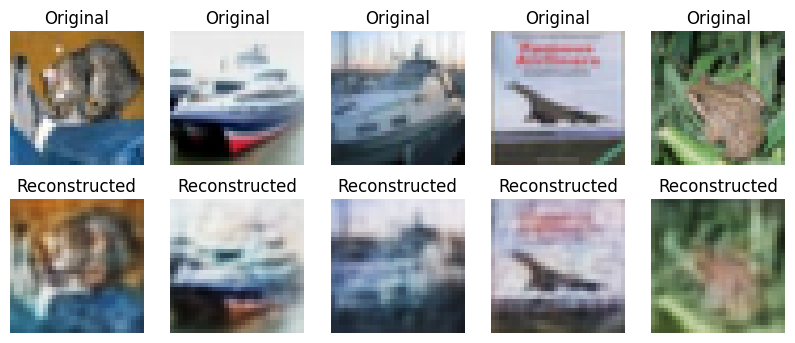

In [ ]:
# Visualize Reconstructions
model.eval()
with torch.no_grad():
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    flat_img = images.view(images.size(0), -1)
    _, output = model(flat_img)
    output = output.view(-1, 3, 32, 32)

    # Denormalize for plotting
    images = images * 0.5 + 0.5
    output = output * 0.5 + 0.5

    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
    for i in range(5):
        axes[0, i].imshow(images[i].permute(1, 2, 0))
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')
        axes[1, i].imshow(output[i].permute(1, 2, 0))
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')
    plt.show()
